# Three-Experiment Comparison: Heuristic vs Physics-Only vs Physics+Sim2Real

Compares three skinning-weight configurations for Simplicits tissue simulation on StereoMIS data.

| Exp | Method | Training losses |
|-----|--------|-----------------|
| **A** | Heuristic (spatial Voronoi, **no training**) | — |
| **B** | Physics-only | $\lambda_e \mathcal{L}_e + \lambda_o \mathcal{L}_o$ |
| **C** | Physics + Sim2Real | $\lambda_e \mathcal{L}_e + \lambda_o \mathcal{L}_o + \lambda_s \mathcal{L}_s$ |

**Evaluation protocol:**
* **Train segment** `ti ∈ [0, TRAIN_T)`: cold-start from frame 0, follow tool trajectory.
* **Test segment** `ti ∈ [TEST_T0, TEST_T1)`: cold-start from `TEST_T0`, follow tool
  displacement **relative to** `tool_t[TEST_T0]` — no future trajectory seen during training.


## 0 · Configuration

In [1]:
# ================================================================
# CONFIG  ← edit before running
# ================================================================
import os

PLOTS_OUTPUT_DIR  = "./compare_3exp_plots"
TRAINING_LOG_DIR  = "./runs_3exp_compare"

NUM_HANDLES       = 8
TRAIN_T           = 60       # training frames: ti in [0, TRAIN_T)
                              # TEST_T0 = TRAIN_T (set after loading tool data)

LAMBDA_E          = 1e-1     # elastic loss coefficient
LAMBDA_O          = 1e9      # orthogonality loss (raised to avoid uniform collapse)
TRAINING_STEPS_B  = 20000    # Exp B: physics-only
TRAINING_STEPS_C  = 20000    # Exp C: physics + sim2real

LS_COEFF          = 0.3      # sim2real Chamfer loss coefficient (Exp C)
HEURISTIC_TYPE    = "spatial" # "uniform" | "spatial" | "random_init"

QP_SEED           = 42       # reproducible quadrature point sampling

os.makedirs(PLOTS_OUTPUT_DIR, exist_ok=True)
os.makedirs(TRAINING_LOG_DIR, exist_ok=True)
print(f"Plots  → {os.path.abspath(PLOTS_OUTPUT_DIR)}")
print(f"Runs   → {os.path.abspath(TRAINING_LOG_DIR)}")


Plots  → /home/nan/Desktop/kaolin/examples/tutorial/physics/compare_3exp_plots
Runs   → /home/nan/Desktop/kaolin/examples/tutorial/physics/runs_3exp_compare


## 1 · Imports

In [2]:
import sys, pickle, json, time, threading, csv
from datetime import datetime

import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import pandas as pd
import ipywidgets as widgets
from IPython.display import display
import k3d
from tqdm.auto import tqdm

sys.path.insert(0, "/home/nan/Desktop/kaolin")
import kaolin as kal
import kaolin.physics.simplicits.easy_api_sim2real_UPDATED_anchor_boundary_fastckpt_v3 as ez
from kaolin.physics.simplicits.network import SimplicitsMLP
from kaolin.physics.simplicits.easy_api_sim2real_UPDATED_anchor_boundary_fastckpt_v3 import NormalizedSkinningWeightsFcn

print("kaolin:", kal.__file__)
print("torch:", torch.__version__, "  CUDA:", torch.cuda.is_available())


kaolin: /home/nan/Desktop/kaolin/kaolin/__init__.py
torch: 2.8.0+cu129   CUDA: True


## 2 · Load tissue point cloud

In [3]:
pkl_file_path = "/home/nan/Desktop/datasets/xpbd/StereoMIS_tissue_tool_trajectories_XPBD/sim_particles/tissue_pts_dnsampled_once.pkl"

with open(pkl_file_path, "rb") as f:
    real_seq = pickle.load(f)

print(type(real_seq), "  frames:", len(real_seq))
print("keys:",  real_seq[0].keys())
print("xyz:",   np.asarray(real_seq[0]["xyz"]).shape)


<class 'list'>   frames: 200
keys: dict_keys(['frame_id', 'xyz', 'rgb', 'opacity', 'indices'])
xyz: (38426, 3)


## 3 · Rest frame (video frame 75) and normalisation

In [4]:
rest_frame_idx = 75   # first frame at which the tool appears

_rest_list_idx = next(
    i for i, fr in enumerate(real_seq) if int(fr["frame_id"]) == rest_frame_idx
)

xyz = np.asarray(real_seq[_rest_list_idx]["xyz"], dtype=np.float32)
N   = xyz.shape[0]
print(f"Rest frame: id={rest_frame_idx}  list_idx={_rest_list_idx}  N={N}")

pts_raw    = torch.from_numpy(xyz).cuda()
mn         = pts_raw.min(dim=0).values
mx         = pts_raw.max(dim=0).values
center_raw = 0.5 * (mn + mx)
scale_raw  = float((0.5 * (mx - mn)).max().item())

pts      = (pts_raw - center_raw) / max(scale_raw, 1e-8)
orig_pts = pts.clone()

print("raw bbox:   ", mn.cpu().numpy(), mx.cpu().numpy())
print("center_raw:", center_raw.cpu().numpy(), "  scale_raw:", scale_raw)
print("normed bbox:", pts.min(0).values.cpu().numpy(), pts.max(0).values.cpu().numpy())


Rest frame: id=75  list_idx=75  N=45038
raw bbox:    [-0.8533555 -1.0274289  0.5846553] [0.67263234 0.4106261  1.8220112 ]
center_raw: [-0.0903616  -0.30840138  1.2033333 ]   scale_raw: 0.7629939317703247
normed bbox: [-1.         -0.94237643 -0.8108557 ] [1.         0.94237643 0.8108557 ]


## 4 · Normalise all real frames

In [5]:
real_xyz_norm  = []
real_frame_ids = []
for fr in real_seq:
    real_frame_ids.append(int(fr["frame_id"]))
    xyz_t    = torch.from_numpy(np.asarray(fr["xyz"], dtype=np.float32)).to(pts.device)
    xyz_norm = (xyz_t - center_raw) / max(scale_raw, 1e-8)
    real_xyz_norm.append(xyz_norm)

real_frame_to_xyz = {fid: xyz for fid, xyz in zip(real_frame_ids, real_xyz_norm)}
print("Loaded real frames:", real_frame_ids[0], "->", real_frame_ids[-1])


Loaded real frames: 0 -> 199


## 5 · Material fields

In [6]:
yms  = torch.full((N,), 2e5,   device=pts.device, dtype=pts.dtype)
prs  = torch.full((N,), 0.45,  device=pts.device, dtype=pts.dtype)
rhos = torch.full((N,), 1000., device=pts.device, dtype=pts.dtype)

mn_n, mx_n   = pts.min(0).values, pts.max(0).values
approx_volume = max(float(torch.prod(mx_n - mn_n).item()), 1e-6)
print("approx_volume:", approx_volume)


approx_volume: 6.11305046081543


## 6 · Tool trajectory and train/test split

`TRAIN_T = 60` frames are used for training (sim2real supervision in Exp C).
The remaining frames form the **test segment** which is never seen during training.


In [7]:
tool_pkl_path = "/home/nan/Desktop/datasets/xpbd/StereoMIS_tissue_tool_trajectories_XPBD/sim_particles/tool_3d_poses.pkl"
with open(tool_pkl_path, "rb") as f:
    tool_data = pickle.load(f)

frame_ids   = sorted(tool_data.keys())
tool_t_raw  = np.stack([np.asarray(tool_data[k]["t"], dtype=np.float32) for k in frame_ids])
tool_R_raw  = np.stack([np.asarray(tool_data[k]["R"], dtype=np.float32) for k in frame_ids])

tool_t_raw_t = torch.from_numpy(tool_t_raw).to(device=pts.device, dtype=pts.dtype)
tool_R       = torch.from_numpy(tool_R_raw).to(device=pts.device, dtype=pts.dtype)
tool_t       = (tool_t_raw_t - center_raw) / max(scale_raw, 1e-8)

# Keep only tool frames that also have real observations
aligned_frame_ids     = [fid for fid in frame_ids if fid in real_frame_to_xyz]
idx_map               = [frame_ids.index(fid) for fid in aligned_frame_ids]
tool_t                = tool_t[idx_map]
tool_R                = tool_R[idx_map]
frame_ids             = aligned_frame_ids
real_xyz_norm_aligned = [real_frame_to_xyz[fid] for fid in frame_ids]

T_total = len(frame_ids)
TEST_T0 = TRAIN_T
TEST_T1 = T_total

assert TRAIN_T < T_total, f"TRAIN_T={TRAIN_T} >= T_total={T_total}"

print(f"Total frames : {T_total}  (video {frame_ids[0]} .. {frame_ids[-1]})")
print(f"Train segment: ti ∈ [0, {TRAIN_T})  frames {frame_ids[0]} .. {frame_ids[TRAIN_T-1]}")
print(f"Test  segment: ti ∈ [{TEST_T0}, {TEST_T1})  frames {frame_ids[TEST_T0]} .. {frame_ids[-1]}")
print(f"Sim2Real supervision: only train frames are used (Exp C)")


Total frames : 125  (video 75 .. 199)
Train segment: ti ∈ [0, 60)  frames 75 .. 134
Test  segment: ti ∈ [60, 125)  frames 135 .. 199
Sim2Real supervision: only train frames are used (Exp C)


## 7 · Exp A — Heuristic (no training)

Spatial Voronoi weighting: k-means centres, softmax-distance assignment.
No gradient descent; purely geometric assignment of handles.


In [8]:
H = NUM_HANDLES   # MLP output size; wrapper appends +1 constant handle

if HEURISTIC_TYPE == "uniform":
    def heuristic_weight_fn(x):
        base  = torch.full((x.shape[0], H), 1.0 / H, device=x.device, dtype=x.dtype)
        const = torch.ones((x.shape[0], 1), device=x.device, dtype=x.dtype)
        return torch.cat([base, const], dim=1)

elif HEURISTIC_TYPE == "spatial":
    from sklearn.cluster import KMeans
    pts_np    = pts.detach().cpu().numpy()
    kmeans    = KMeans(n_clusters=H, random_state=42, n_init=10).fit(pts_np)
    _hlocs    = torch.from_numpy(kmeans.cluster_centers_.astype(np.float32)).to(pts.device)
    _TEMP     = 0.1   # softmax temperature (lower → harder)

    print("K-Means handle locations (normed):")
    for i, loc in enumerate(_hlocs):
        print(f"  handle {i}: {loc.cpu().numpy()}")

    def heuristic_weight_fn(x):
        d    = torch.cdist(x, _hlocs)                       # (N, H)
        base = torch.softmax(-d / _TEMP, dim=1)             # (N, H) soft Voronoi
        const = torch.ones((x.shape[0], 1), device=x.device, dtype=x.dtype)
        return torch.cat([base, const], dim=1)              # (N, H+1)

elif HEURISTIC_TYPE == "random_init":
    _rand_model = SimplicitsMLP(3, 64, H, 6).to(pts.device)
    _rand_model.eval()
    _bb_min = pts.min(dim=0).values
    _bb_max = pts.max(dim=0).values

    class _RandInitFcn(torch.nn.Module):
        def __init__(self, m, bb_min, bb_max):
            super().__init__(); self.m = m
            self.bb_min = bb_min; self.bb_max = bb_max
        @torch.no_grad()
        def forward(self, x):
            n = (x - self.bb_min) / (self.bb_max - self.bb_min).clamp_min(1e-8)
            logits = self.m(n)
            return torch.cat([logits, torch.ones(x.shape[0], 1, device=x.device, dtype=x.dtype)], dim=1)

    heuristic_weight_fn = _RandInitFcn(_rand_model, _bb_min, _bb_max)
else:
    raise ValueError(f"Unknown HEURISTIC_TYPE: {HEURISTIC_TYPE!r}")

sim_obj_A = ez.SimplicitsObject.create_from_function(
    pts, yms, prs, rhos, approx_volume, fcn=heuristic_weight_fn
)
print("Exp A (heuristic):", sim_obj_A, "  type:", HEURISTIC_TYPE)


K-Means handle locations (normed):
  handle 0: [ 0.03337542 -0.3255992   0.12881236]
  handle 1: [-0.2858803   0.7615703  -0.34531265]
  handle 2: [ 0.7061389   0.19488165 -0.09010383]
  handle 3: [-0.3989904   0.11842823  0.5445917 ]
  handle 4: [-0.5129378   0.60518014 -0.04210991]
  handle 5: [ 0.55638486 -0.24711776  0.37642658]
  handle 6: [0.231794   0.24438336 0.18070064]
  handle 7: [ 0.7248089   0.6749363  -0.16703723]
Exp A (heuristic): <kaolin.physics.simplicits.easy_api_sim2real_UPDATED_anchor_boundary_fastckpt_v3.SimplicitsObject object at 0x71f518d2b670>   type: spatial


## 8 · Exp B — Physics-only training

Minimises $\lambda_e \mathcal{L}_e + \lambda_o \mathcal{L}_o$.
No sim2real loss; purely physics-based regularisation.
Checkpoints are saved in a **fixed** directory so re-running resumes training.


In [9]:
dir_b = os.path.join(TRAINING_LOG_DIR, f"expB_H{NUM_HANDLES}_lo{LAMBDA_O:.0e}")
os.makedirs(dir_b, exist_ok=True)
print(f"Exp B log dir: {dir_b}")

sim_obj_B, logs_B = ez.SimplicitsObject.create_trained(
    pts, yms, prs, rhos, approx_volume,
    num_handles            = NUM_HANDLES,
    training_num_steps     = TRAINING_STEPS_B,
    training_lr_start      = 1e-3,
    training_lr_end        = 1e-3,
    training_le_coeff      = LAMBDA_E,
    training_lo_coeff      = LAMBDA_O,
    training_ls_coeff      = 0.0,          # no sim2real
    training_log_every     = 100,
    normalize_for_training = True,
    training_batch_size    = 10,
    num_samples            = 800,
    training_save_every    = 500,
    training_eval_every    = 500,
    training_resume        = True,
    training_log_dir       = dir_b,
    training_return_logs   = True,
)
print("Exp B:  num_handles:", sim_obj_B.num_handles)
print("        Log CSV:    ", sim_obj_B.training_log_csv)


Exp B log dir: ./runs_3exp_compare/expB_H8_lo1e+09


  0%|          | 0/20000 [00:00<?, ?it/s]

## 9 · Exp C — Physics + Sim2Real training

Adds a **Chamfer alignment loss** computed on the *train segment only*:

$$\mathcal{L}_s = \frac{1}{T_{\text{train}}} \sum_{t=0}^{T_{\text{train}}-1}
d_{\text{Chamfer}}\!\left(\hat{\mathcal{X}}_t,\, \mathcal{X}_t^{\text{real}}\right)$$

Simulation state $Z_t$ is obtained by rolling out the physics solver with **detached** weights,
then differentiating $\hat{x} = \sum_h w_h(x)\, T_h\, x$ w.r.t. the MLP weights only.


In [ ]:
dir_c = os.path.join(TRAINING_LOG_DIR,
                     f"expC_H{NUM_HANDLES}_lo{LAMBDA_O:.0e}_ls{LS_COEFF}")
os.makedirs(dir_c, exist_ok=True)
print(f"Exp C log dir: {dir_c}")

sim_obj_C, logs_C = ez.SimplicitsObject.create_trained(
    pts, yms, prs, rhos, approx_volume,
    num_handles               = NUM_HANDLES,
    training_num_steps        = TRAINING_STEPS_C,
    training_lr_start         = 1e-3,
    training_lr_end           = 1e-3,
    training_le_coeff         = LAMBDA_E,
    training_lo_coeff         = LAMBDA_O,
    training_ls_coeff         = LS_COEFF,
    training_log_every        = 100,
    normalize_for_training    = True,
    training_batch_size       = 10,
    num_samples               = 800,
    training_save_every       = 500,
    training_eval_every       = 500,
    training_resume           = True,
    training_log_dir          = dir_c,
    training_return_logs      = True,
    # ── sim2real supervision (train frames only) ───────────────
    sim2real_real_frames      = real_xyz_norm_aligned,
    sim2real_train_range      = (0, TRAIN_T),
    sim2real_num_pts_sim      = 1024,
    sim2real_num_pts_real     = 1024,
    sim2real_tool_t           = tool_t,
    sim2real_tool_R           = tool_R,
    sim2real_use_rotation     = False,
    sim2real_scene_num_qp     = 800,
    sim2real_scene_timestep   = 0.01,
    sim2real_scene_newton_steps = 30,
    sim2real_max_steps_per_call = 50,
    sim2real_anchor_enable    = True,
    sim2real_anchor_eps_ratio = 0.03,
    sim2real_anchor_penalty   = 1e7,
    sim2real_grasp_penalty    = 1e5,
    sim2real_every            = 50,
    sim2real_warmup_steps     = 5000,   # first 5000 steps: physics-only warmup
)
print("Exp C:  num_handles:", sim_obj_C.num_handles)
print("        Log CSV:    ", sim_obj_C.training_log_csv)


## 8b · Load from checkpoint (optional — replaces §8 & §9)

Run this cell **instead of** §8 and §9 when checkpoints already exist.
Set `CKPT_B` / `CKPT_C` to `None` to fall back to the trained objects from §8/§9.

Default paths follow the naming convention used by `create_trained` (auto-detected from `TRAINING_LOG_DIR` / config).

In [27]:
# ── Master switch ────────────────────────────────────────────────────────────
LOAD_FROM_CKPT = True   # True  → load weights below, skip §8/§9 training
                         # False → use sim_obj_B / sim_obj_C trained live in §8/§9

# ── Checkpoint paths (only used when LOAD_FROM_CKPT = True) ─────────────────
CKPT_B = os.path.join(
    TRAINING_LOG_DIR,
    f"expB_H{NUM_HANDLES}_lo{LAMBDA_O:.0e}",
    "checkpoints", "ckpt_step_0019999.pt"
)
CKPT_C = os.path.join(
    TRAINING_LOG_DIR,
    f"expC_H{NUM_HANDLES}_lo{LAMBDA_O:.0e}_ls{LS_COEFF}",
    "checkpoints", "ckpt_step_0019999.pt"
)

# # ── Override with explicit absolute paths if needed ──────────────────────────
# CKPT_B = "/home/nan/Desktop/kaolin/examples/tutorial/physics/"\
#          "with_sim2real_runs_3exp_compare/runs_3exp_compare/"\
#          "expB_H5_lo1e+08/checkpoints/ckpt_step_0014999.pt"
# CKPT_C = "/home/nan/Desktop/kaolin/examples/tutorial/physics/"\
#          "with_sim2real_runs_3exp_compare/runs_3exp_compare/"\
#          "expC_H5_lo1e+08_ls1.0/checkpoints/ckpt_step_0014999.pt"

def load_sim_obj_from_checkpoint(ckpt_path, pts, yms, prs, rhos, approx_volume,
                                   num_handles, log_dir, model_layers=6):
    """Reconstruct a SimplicitsObject from a saved .pt checkpoint."""
    print(f"  Loading: {ckpt_path}")
    ckpt  = torch.load(ckpt_path, map_location=pts.device, weights_only=False)
    model = SimplicitsMLP(3, 64, num_handles, model_layers).to(pts.device)
    model.load_state_dict(ckpt.get("model", ckpt))
    model.eval()
    bb_min = pts.min(dim=0).values
    bb_max = pts.max(dim=0).values
    fcn = NormalizedSkinningWeightsFcn(model, bb_min, bb_max)
    obj = ez.SimplicitsObject.create_from_function(
        pts, yms, prs, rhos, approx_volume, fcn=fcn)
    obj.training_log_dir = log_dir
    obj.training_log_csv = os.path.join(log_dir, "train_losses.csv")
    step = ckpt.get("step", "?")
    print(f"    loaded step={step}  num_handles={obj.num_handles}")
    return obj

if LOAD_FROM_CKPT:
    # ── Load Exp B from checkpoint ────────────────────────────────────────────
    dir_b = os.path.join(TRAINING_LOG_DIR, f"expB_H{NUM_HANDLES}_lo{LAMBDA_O:.0e}")
    if os.path.exists(CKPT_B):
        sim_obj_B = load_sim_obj_from_checkpoint(
            CKPT_B, pts, yms, prs, rhos, approx_volume, NUM_HANDLES, dir_b)
        logs_B = None
        print("Exp B loaded from checkpoint ✓")
    else:
        print(f"WARNING: CKPT_B not found at {CKPT_B}")
        print("         Run §8 first or fix the path above.")

    # ── Load Exp C from checkpoint ────────────────────────────────────────────
    dir_c = os.path.join(TRAINING_LOG_DIR,
                         f"expC_H{NUM_HANDLES}_lo{LAMBDA_O:.0e}_ls{LS_COEFF}")
    if os.path.exists(CKPT_C):
        sim_obj_C = load_sim_obj_from_checkpoint(
            CKPT_C, pts, yms, prs, rhos, approx_volume, NUM_HANDLES, dir_c)
        logs_C = None
        print("Exp C loaded from checkpoint ✓")
    else:
        print(f"WARNING: CKPT_C not found at {CKPT_C}")
        print("         Run §9 first or fix the path above.")
else:
    print("LOAD_FROM_CKPT = False — using sim_obj_B / sim_obj_C from §8/§9.")
    print(f"  Exp B: {sim_obj_B}")
    print(f"  Exp C: {sim_obj_C}")


         Run §8 first or fix the path above.
         Run §9 first or fix the path above.


## 10 · Training loss analysis — Exp B vs C

Plots all loss components per step.
**Exp A** has no training loss (not shown).


In [28]:
EXP_TRAIN_CFG = {
    "B": dict(sim_obj=sim_obj_B, logs=logs_B, label="B: Physics-only",      color="royalblue"),
    "C": dict(sim_obj=sim_obj_C, logs=logs_C, label="C: Physics+Sim2Real",  color="darkorange"),
}

for exp_key, cfg in EXP_TRAIN_CFG.items():
    csv_path = cfg["sim_obj"].training_log_csv
    if not os.path.exists(csv_path):
        print(f"  Exp {exp_key}: CSV not found at {csv_path}")
        continue
    cfg["df"] = pd.read_csv(csv_path)
    print(f"  Exp {exp_key}: {len(cfg['df'])} training rows  →  {csv_path}")

# ── Loss component comparison B vs C ─────────────────────────────────────────
loss_cols = [c for c in EXP_TRAIN_CFG["B"].get("df", pd.DataFrame()).columns
             if c not in ("step", "lr", "elapsed_s", "grad_norm")]

fig, axes = plt.subplots(len(loss_cols), 1, figsize=(13, 3.5 * len(loss_cols)), sharex=False)
if len(loss_cols) == 1:
    axes = [axes]
fig.suptitle("Training Loss Components — Exp B vs C", fontsize=14)

for ax, col in zip(axes, loss_cols):
    for exp_key, cfg in EXP_TRAIN_CFG.items():
        df = cfg.get("df")
        if df is None or col not in df.columns:
            continue
        vals = df[col].clip(lower=0)
        ax.plot(df["step"], vals,             alpha=0.5, lw=1, color=cfg["color"])
        ax.plot(df["step"], vals.rolling(50, min_periods=1).mean(),
                lw=2, color=cfg["color"], label=cfg["label"])
    if col == "ls":
        ax.axvline(2000, color="gray", ls=":", lw=1, label="sim2real warmup end (C)")
    ax.set_ylabel(col); ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Training step")
plt.tight_layout()
p = os.path.join(PLOTS_OUTPUT_DIR, "01_training_loss_B_vs_C.png")
plt.savefig(p, dpi=150, bbox_inches="tight")
print("Saved:", p)
plt.show()

# ── Relative improvement B→C for each loss ───────────────────────────────────
print("\nFinal 500-step average losses:")
for exp_key, cfg in EXP_TRAIN_CFG.items():
    df = cfg.get("df")
    if df is None: continue
    tail = df.tail(500)
    print(f"  Exp {exp_key}:", {c: f"{tail[c].mean():.4g}" for c in loss_cols if c in tail})


  Exp B: CSV not found at ./runs_3exp_compare/expB_H8_lo1e+09/train_losses.csv
  Exp C: CSV not found at ./runs_3exp_compare/expC_H8_lo1e+09_ls0.3/train_losses.csv


ValueError: Number of rows must be a positive integer, not 0

<Figure size 1300x0 with 0 Axes>

## 11 · Skinning weight quality analysis — all 3 experiments

In [47]:
@torch.no_grad()
def compute_weight_stats(sim_obj, label, subsample=8000):
    idx   = torch.randperm(pts.shape[0])[:subsample]
    pts_s = pts[idx]
    w_full = sim_obj.skinning_weight_function(pts_s)   # (sub, H+1)
    w_raw  = w_full[:, :-1].detach().cpu().numpy()     # (sub, H) drop constant column
    pts_np = pts_s.detach().cpu().numpy()

    # argmax is invariant under softmax, so w_raw works for dominant regardless
    dominant  = np.argmax(w_raw, axis=1)
    val_range = w_raw.max(axis=1) - w_raw.min(axis=1)  # per-point max-minus-min
    val_std   = w_raw.std(axis=1)                       # per-point std across handles

    W_zm  = w_raw - w_raw.mean(axis=0)
    W_norm = W_zm / (W_zm.std(axis=0) + 1e-8)
    gram  = (W_norm.T @ W_norm) / w_raw.shape[0]

    return dict(pts=pts_np, w_raw=w_raw,
                dominant=dominant, val_range=val_range, val_std=val_std,
                gram=gram, per_handle=w_raw, label=label)

EXP_WEIGHT_CFG = [
    ("A_heuristic", sim_obj_A, f"A: Heuristic ({HEURISTIC_TYPE})", "tomato"),
    ("B_physics",   sim_obj_B, f"B: Physics-only (H={NUM_HANDLES}, {TRAINING_STEPS_B} steps)", "royalblue"),
    ("C_sim2real",  sim_obj_C, f"C: Physics+Sim2Real ({TRAINING_STEPS_C} steps)", "mediumseagreen"),
]

# What w_raw actually contains per experiment — affects how to interpret magnitude.
# A: softmax probabilities (magnitude meaningful, range in [0,1])
# B/C: raw MLP logits (magnitude is arbitrary; only distribution shape is meaningful)
EXP_VALUE_TYPE = {
    "A_heuristic": "weights are softmax probs",
    "B_physics":   "weights are raw MLP logits",
    "C_sim2real":  "weights are raw MLP logits",
}

weight_stats = {}
for key, sim_obj, label, color in EXP_WEIGHT_CFG:
    print(f"Computing weight stats: {label} ...")
    weight_stats[key] = compute_weight_stats(sim_obj, label)
    weight_stats[key]["color"] = color

# ── Quantitative table ────────────────────────────────────────────────────────
print("\n=== Per-point max−min spread ===")
print("  (A = prob spread, magnitude in [0,1]; B/C = logit spread, shape only)")
header = f"  {'Metric':<40}" + "".join(f" {cfg[2]:>18}" for cfg in EXP_WEIGHT_CFG)
print(header)
print("  " + "-" * (40 + 19 * len(EXP_WEIGHT_CFG)))
for metric_lbl, arr_key in [
    ("max−min  mean", "val_range"),
    ("std    mean", "val_std"),
]:
    row = f"  {metric_lbl:<40}"
    for key, _, _, _ in EXP_WEIGHT_CFG:
        row += f" {weight_stats[key][arr_key].mean():>18.4f}"
    print(row)

print("\n  Handle dominance (# points dominant):")
for h in range(NUM_HANDLES):
    row = f"  Handle {h:<3}"
    for key, _, _, _ in EXP_WEIGHT_CFG:
        row += f" {(weight_stats[key]['dominant'] == h).sum():>18d}"
    print(row)


Computing weight stats: A: Heuristic (spatial) ...
Computing weight stats: B: Physics-only (H=8, 20000 steps) ...
Computing weight stats: C: Physics+Sim2Real (20000 steps) ...

=== Per-point max−min spread ===
  (A = prob spread, magnitude in [0,1]; B/C = logit spread, shape only)
  Metric                                   A: Heuristic (spatial) B: Physics-only (H=8, 20000 steps) C: Physics+Sim2Real (20000 steps)
  -------------------------------------------------------------------------------------------------
  max−min  mean                                        0.8656             0.1060             0.1031
  std    mean                                          0.2868             0.0325             0.0323

  Handle dominance (# points dominant):
  Handle 0                 1273                293               2311
  Handle 1                 1740               1836                 11
  Handle 2                  797                 33                400
  Handle 3                  455 

## 12 · Skinning weight plots — all 3 experiments

/tmp/ipykernel_2677910/3139725582.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_h = plt.cm.get_cmap("tab10", NUM_HANDLES)
/tmp/ipykernel_2677910/3139725582.py:18: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved: ./compare_3exp_plots/02_dominant_handle_3exp.png


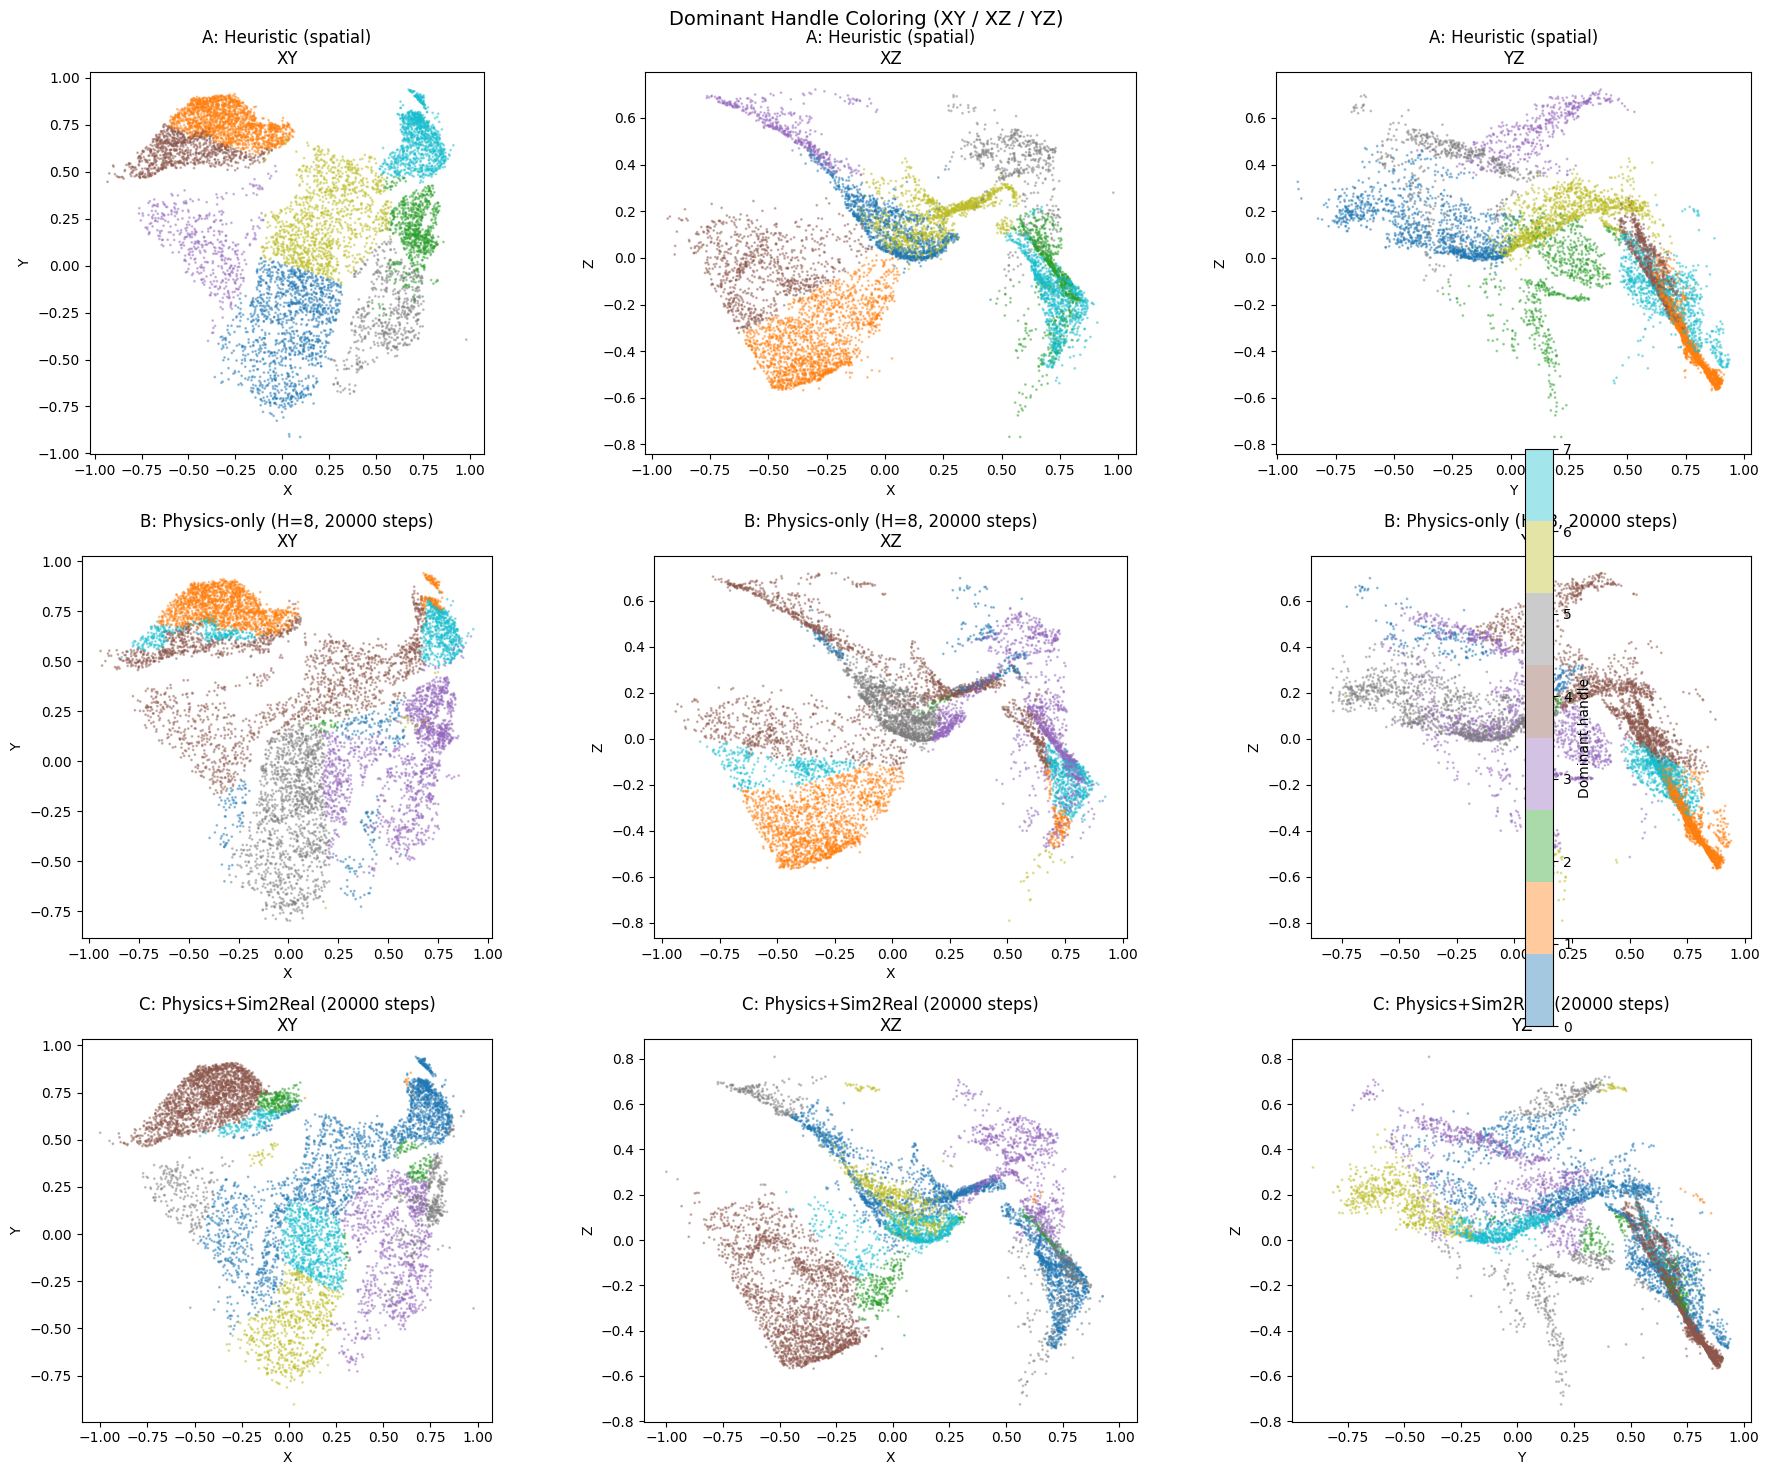

Saved: ./compare_3exp_plots/03_logit_spread_3exp.png


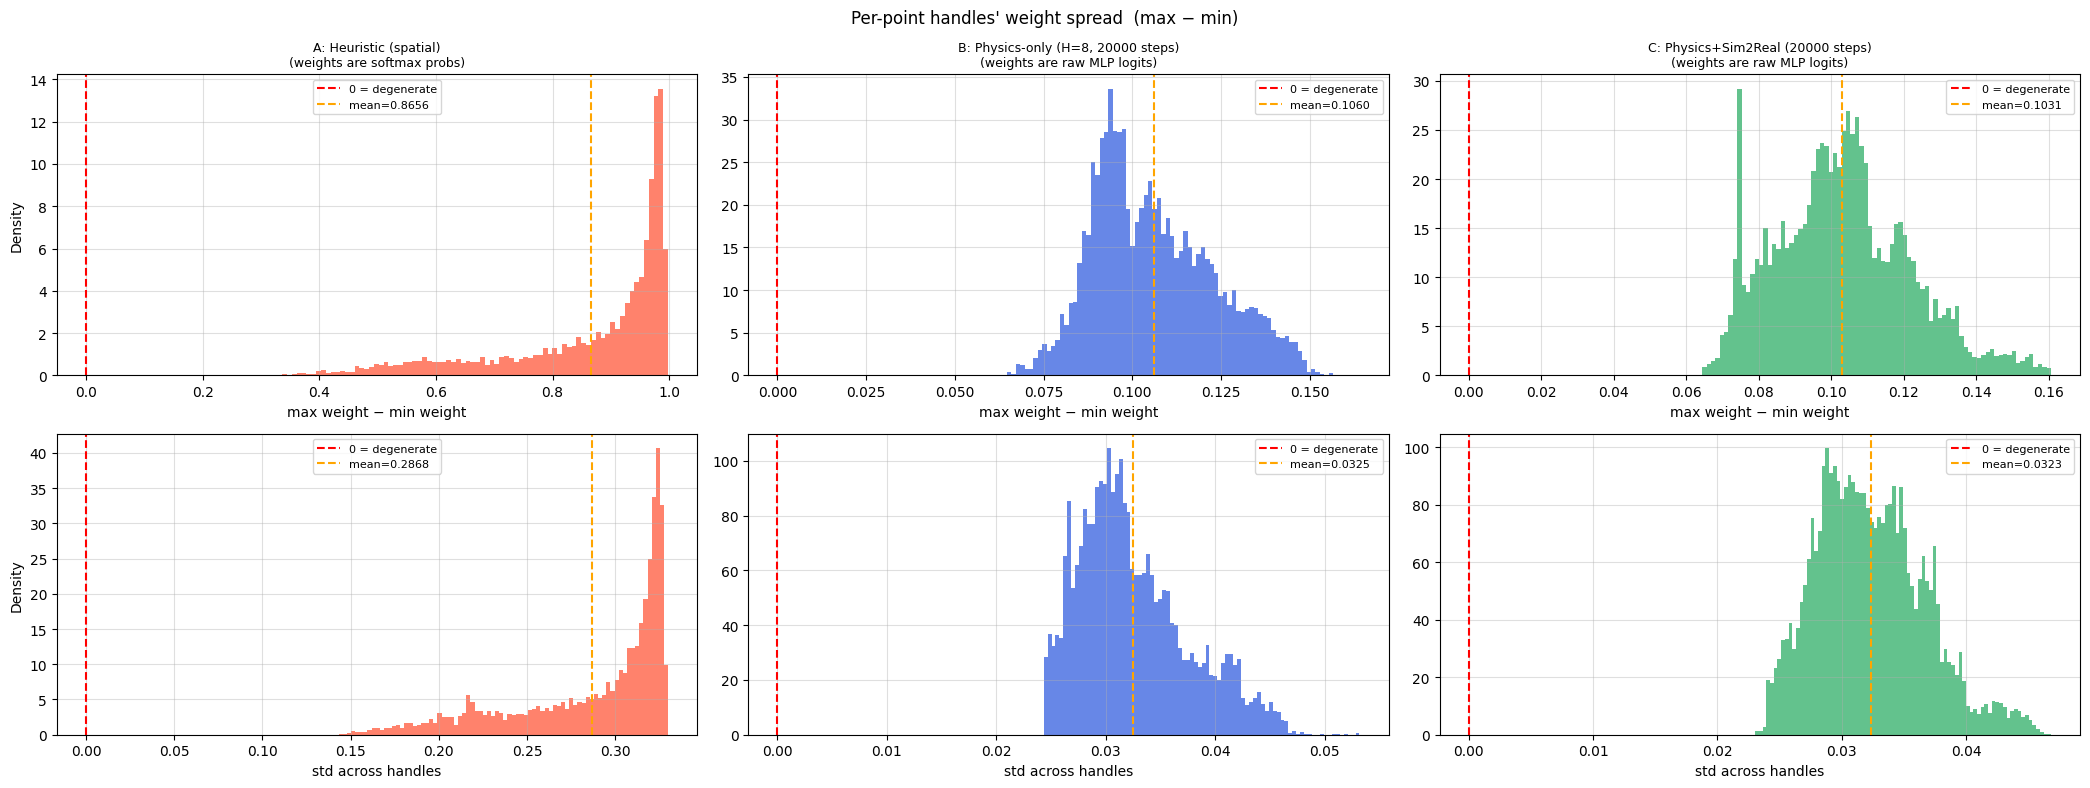

Saved: ./compare_3exp_plots/04_per_handle_maps_3exp.png


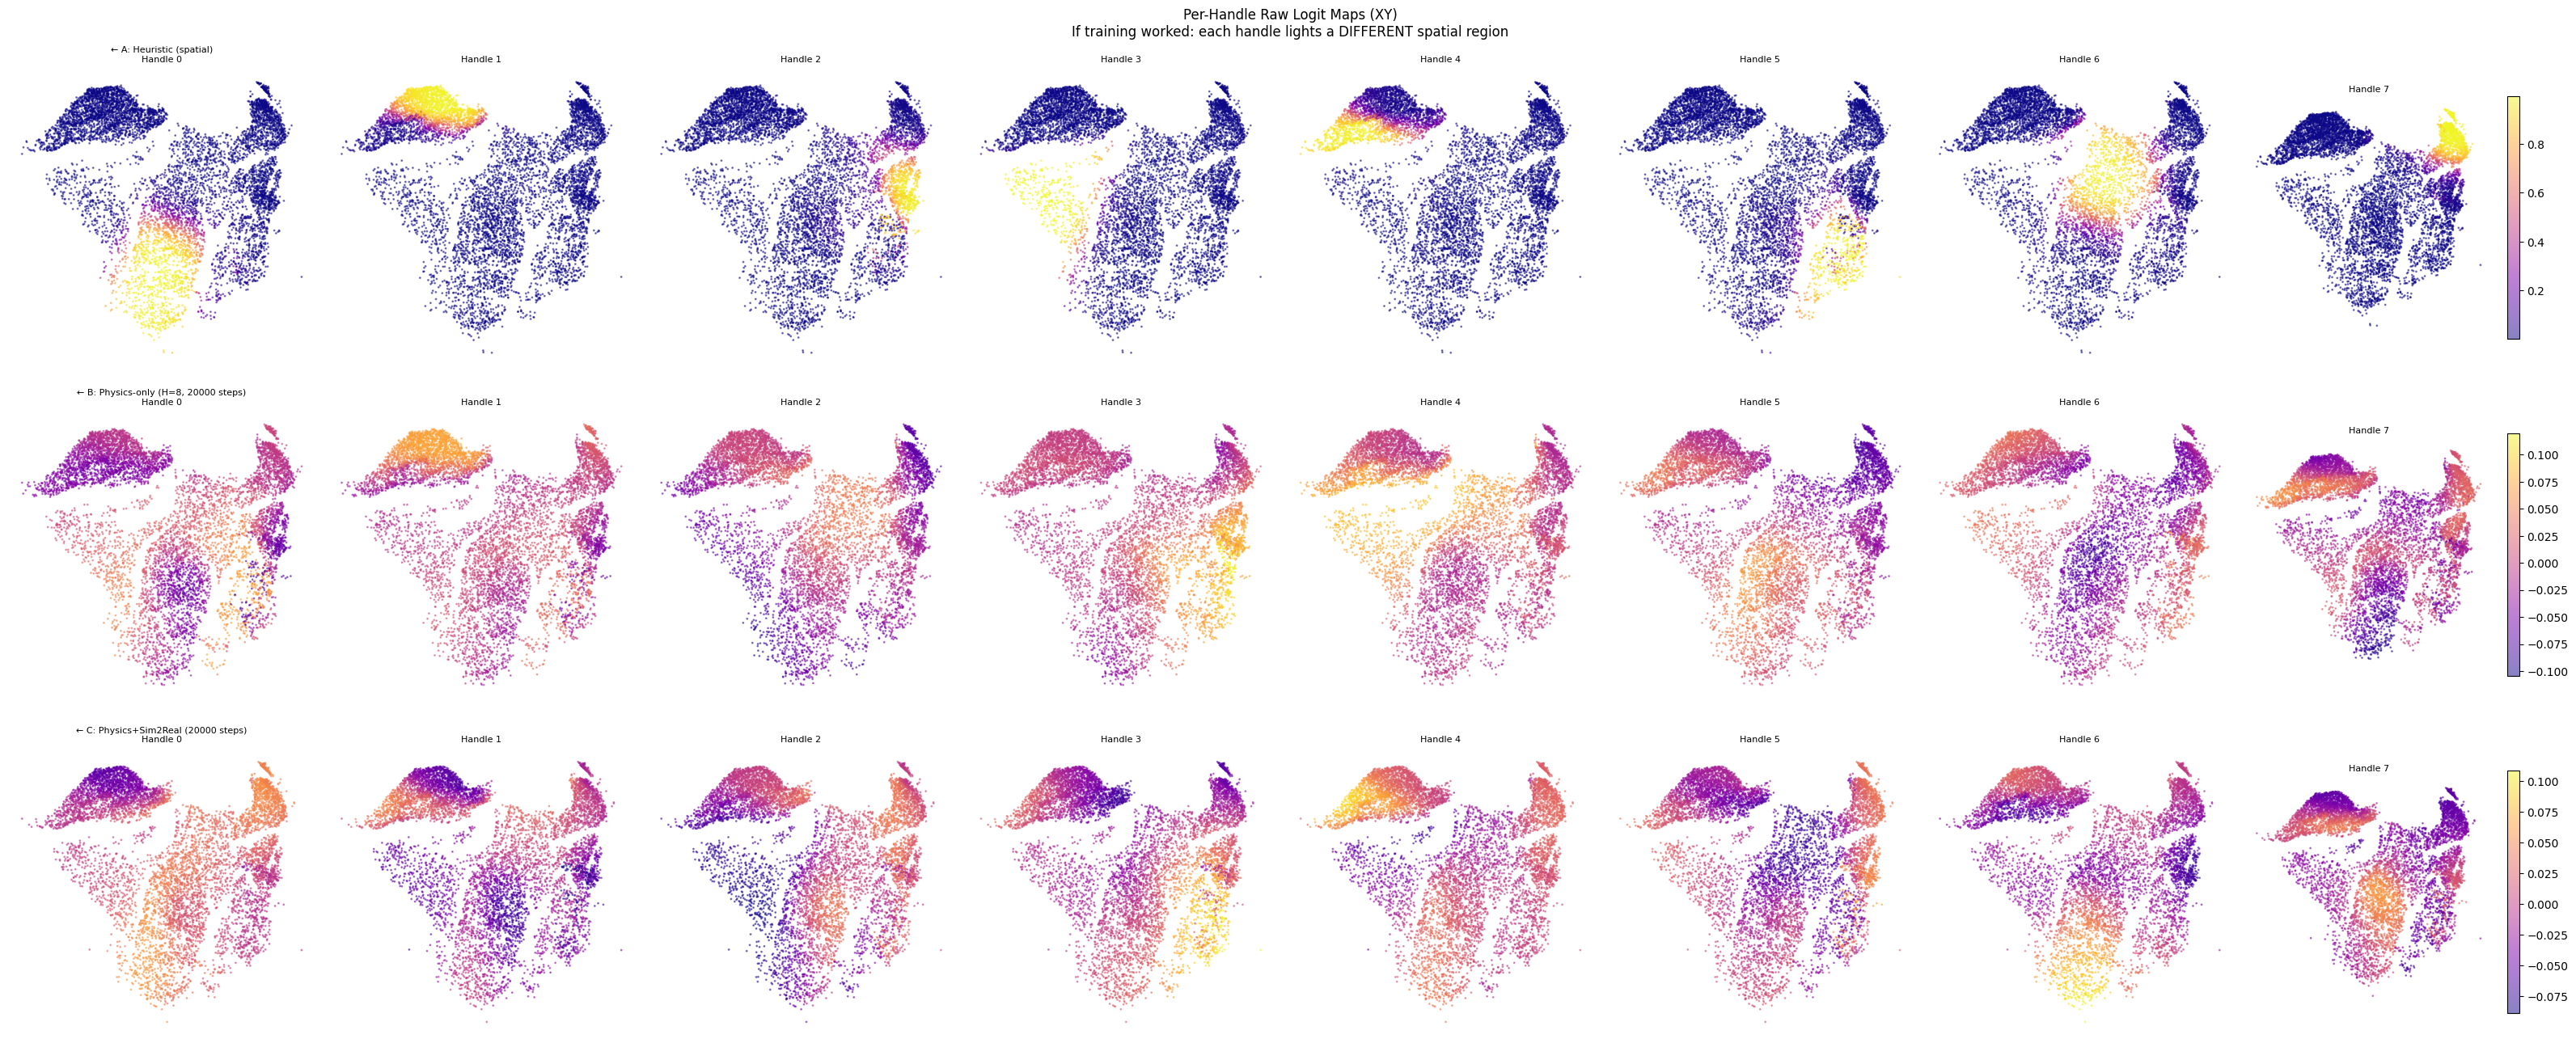

Saved: ./compare_3exp_plots/05_handle_correlation_3exp.png


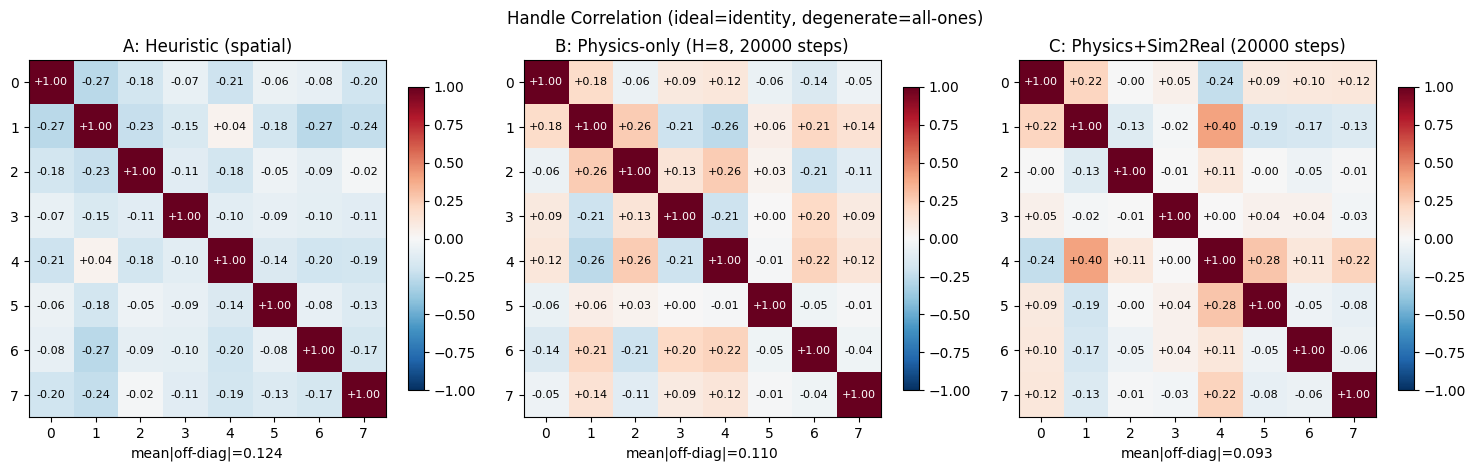

In [53]:
# ── Plot A: dominant handle coloring ─────────────────────────────────────────
cmap_h = plt.cm.get_cmap("tab10", NUM_HANDLES)
n_exp  = len(EXP_WEIGHT_CFG)

fig, axes = plt.subplots(n_exp, 3, figsize=(18, 5 * n_exp))
fig.suptitle("Dominant Handle Coloring (XY / XZ / YZ)", fontsize=14)
for row_i, (key, _, _, _) in enumerate(EXP_WEIGHT_CFG):
    st  = weight_stats[key]
    dom = st["dominant"]
    for col_i, (xi, yi, vname) in enumerate([(0,1,"XY"),(0,2,"XZ"),(1,2,"YZ")]):
        ax = axes[row_i, col_i]
        sc_ = ax.scatter(st["pts"][:, xi], st["pts"][:, yi],
                         c=dom, cmap=cmap_h, vmin=0, vmax=NUM_HANDLES-1, s=1, alpha=0.4)
        ax.set_title(f"{st['label']}\n{vname}")
        ax.set_xlabel(["X","Y","Z"][xi]); ax.set_ylabel(["X","Y","Z"][yi])
        ax.set_aspect("equal")
fig.colorbar(sc_, ax=axes[:, 2], shrink=0.5, label="Dominant handle")
plt.tight_layout()
p = os.path.join(PLOTS_OUTPUT_DIR, "02_dominant_handle_3exp.png")
plt.savefig(p, dpi=150, bbox_inches="tight"); print("Saved:", p); plt.show()

# ── Plot B: per-point max-minus-min spread ───────────────────────────────────
# Exp A: w_raw is softmax probs → range in [0,1], magnitude is meaningful.
# Exp B/C: w_raw is raw MLP logits → arbitrary scale, only distribution shape matters.
fig, axes = plt.subplots(2, n_exp, figsize=(7 * n_exp, 8))
fig.suptitle("Per-point handles' weight spread  (max − min)",
             fontsize=12)
for col_i, (key, _, _, color) in enumerate(EXP_WEIGHT_CFG):
    st   = weight_stats[key]
    vtype = EXP_VALUE_TYPE[key]
    for row_i, (arr_key, row_label) in enumerate([
        ("val_range", "max weight − min weight"),
        ("val_std",   "std across handles"),
    ]):
        ax  = axes[row_i, col_i]
        arr = st[arr_key]
        ax.hist(arr, bins=80, density=True, alpha=0.8, color=color)
        ax.axvline(0.0,        color="red",    ls="--", lw=1.5, label="0 = degenerate")
        ax.axvline(arr.mean(), color="orange", ls="--", lw=1.5, label=f"mean={arr.mean():.4f}")
        title = f"{st['label']}\n({vtype})" if row_i == 0 else ""
        ax.set_title(title, fontsize=9)
        ax.set_xlabel(row_label); ax.set_ylabel("Density" if col_i == 0 else "")
        ax.legend(fontsize=8); ax.grid(True, alpha=0.4)
plt.tight_layout()
p = os.path.join(PLOTS_OUTPUT_DIR, "03_logit_spread_3exp.png")
plt.savefig(p, dpi=150, bbox_inches="tight"); print("Saved:", p); plt.show()

# ── Plot C: per-handle logit maps ────────────────────────────────────────────
fig, axes = plt.subplots(n_exp, NUM_HANDLES, figsize=(NUM_HANDLES * 4, 4.5 * n_exp))
fig.suptitle("Per-Handle Raw Logit Maps (XY)\n"
             "If training worked: each handle lights a DIFFERENT spatial region", fontsize=12)
for row_i, (key, _, _, _) in enumerate(EXP_WEIGHT_CFG):
    st  = weight_stats[key]
    ph  = st["per_handle"]
    vmin_h, vmax_h = ph.min(), ph.max()
    for h in range(NUM_HANDLES):
        ax = axes[row_i, h] if n_exp > 1 else axes[h]
        sc_ = ax.scatter(st["pts"][:, 0], st["pts"][:, 1],
                         c=ph[:, h], cmap="plasma", s=1, alpha=0.5, vmin=vmin_h, vmax=vmax_h)
        ax.set_title(("← " + st["label"] + "\n" if h == 0 else "") + f"Handle {h}", fontsize=8)
        ax.set_aspect("equal"); ax.axis("off")
    fig.colorbar(sc_, ax=(axes[row_i] if n_exp > 1 else axes)[-1], shrink=0.7)
plt.tight_layout()
p = os.path.join(PLOTS_OUTPUT_DIR, "04_per_handle_maps_3exp.png")
plt.savefig(p, dpi=150, bbox_inches="tight"); print("Saved:", p); plt.show()

# ── Plot D: handle correlation matrix ────────────────────────────────────────
fig, axes = plt.subplots(1, n_exp, figsize=(5 * n_exp, 4.5))
fig.suptitle("Handle Correlation (ideal=identity, degenerate=all-ones)", fontsize=12)
for ax, (key, _, _, _) in zip(axes, EXP_WEIGHT_CFG):
    g   = weight_stats[key]["gram"]
    lbl = weight_stats[key]["label"]
    im  = ax.imshow(g, cmap="RdBu_r", vmin=-1, vmax=1)
    for i in range(NUM_HANDLES):
        for j in range(NUM_HANDLES):
            ax.text(j, i, f"{g[i,j]:+.2f}", ha="center", va="center",
                    fontsize=8, color="white" if abs(g[i,j]) > 0.5 else "black")
    off_diag = (np.abs(g) - np.eye(NUM_HANDLES)).mean()
    ax.set_title(lbl); ax.set_xticks(range(NUM_HANDLES)); ax.set_yticks(range(NUM_HANDLES))
    ax.set_xlabel(f"mean|off-diag|={off_diag:.3f}")
    fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
p = os.path.join(PLOTS_OUTPUT_DIR, "05_handle_correlation_3exp.png")
plt.savefig(p, dpi=150, bbox_inches="tight"); print("Saved:", p); plt.show()


## 13 · Simulation scene utilities

In [19]:
def torch_to_np(x):
    return x.detach().cpu().numpy()

@torch.no_grad()
def chamfer_l2(a, b, max_a=2048, max_b=2048):
    if a.shape[0] > max_a:
        a = a[torch.randint(0, a.shape[0], (max_a,), device=a.device)]
    if b.shape[0] > max_b:
        b = b[torch.randint(0, b.shape[0], (max_b,), device=b.device)]
    d   = torch.cdist(a, b)
    ab  = (d.min(dim=1).values ** 2).mean()
    ba  = (d.min(dim=0).values ** 2).mean()
    return ab + ba, torch.sqrt((ab + ba).clamp_min(1e-12))

def build_anchor_mask_cpu(internal_rest, eps_ratio=0.03):
    mins = internal_rest.min(dim=0).values
    maxs = internal_rest.max(dim=0).values
    eps  = eps_ratio * (maxs - mins).clamp_min(1e-8)
    on   = (
        (internal_rest[:, 0] <= mins[0] + eps[0]) | (internal_rest[:, 0] >= maxs[0] - eps[0]) |
        (internal_rest[:, 1] <= mins[1] + eps[1]) | (internal_rest[:, 1] >= maxs[1] - eps[1]) |
        (internal_rest[:, 2] <= mins[2] + eps[2]) | (internal_rest[:, 2] >= maxs[2] - eps[2])
    )
    mask = torch.zeros(internal_rest.shape[0], dtype=torch.bool)
    mask[on.nonzero(as_tuple=False).squeeze(1).cpu()] = True
    return mask

def make_scene(sim_obj, num_qp=800, newton_steps=30, timestep=0.01):
    scene = kal.physics.simplicits.SimplicitsScene()
    scene.max_newton_steps = int(newton_steps)
    scene.timestep         = float(timestep)
    scene.direct_solve     = True
    obj_idx = scene.add_object(sim_obj, num_qp=int(num_qp))
    scene.set_scene_gravity(acc_gravity=torch.zeros(3, device=pts.device, dtype=pts.dtype))
    scene.reset_scene()
    return scene, obj_idx

def compute_constraint_geometry(internal_rest, t_ref_idx=0, eps_ratio=0.03, K_GRASP_PTS=10):
    '''Compute shared anchor/grasp constraint geometry.

    t_ref_idx: index into tool_t used as the reference for grasp_targets.
               0       -> train segment (cold start at t=0)
               TEST_T0 -> test segment (cold start at TEST_T0)
    '''
    t_ref = tool_t[t_ref_idx]
    d2    = torch.sum((internal_rest - t_ref[None, :]) ** 2, dim=1)
    grasp_ids     = torch.topk(d2, k=int(K_GRASP_PTS), largest=False).indices
    grasp_ids_cpu = grasp_ids.cpu()

    grasp_mask_cpu = torch.zeros(internal_rest.shape[0], dtype=torch.bool)
    grasp_mask_cpu[grasp_ids_cpu] = True

    p0      = internal_rest[grasp_ids].clone()
    t_ref_c = t_ref.clone()
    def grasp_targets(ti): return p0 + (tool_t[ti] - t_ref_c)[None, :]

    anchor_mask_cpu = build_anchor_mask_cpu(internal_rest, eps_ratio=float(eps_ratio))
    anchor_mask_cpu[grasp_ids_cpu] = False
    anchor_ids_cpu  = anchor_mask_cpu.nonzero(as_tuple=False).squeeze(1)
    anchor_target   = internal_rest[anchor_ids_cpu.to(internal_rest.device)].clone()

    return dict(
        t_ref_idx       = t_ref_idx,
        internal_rest   = internal_rest,
        grasp_ids       = grasp_ids,
        grasp_ids_cpu   = grasp_ids_cpu,
        grasp_mask_cpu  = grasp_mask_cpu,
        grasp_targets   = grasp_targets,
        p0              = p0,
        anchor_mask_cpu = anchor_mask_cpu,
        anchor_ids_cpu  = anchor_ids_cpu,
        anchor_target   = anchor_target,
    )

def register_constraints(scene, obj_idx, cg, K_ANCHOR=1e7, K_GRASP=1e5):
    '''Register boundary conditions using pre-computed constraint geometry.'''
    _gm = cg["grasp_mask_cpu"]
    _am = cg["anchor_mask_cpu"]
    scene.set_object_boundary_condition(
        obj_idx=obj_idx, name="grasp",
        fcn=lambda _: _gm, bdry_penalty=float(K_GRASP),
        pinned_x=cg["grasp_targets"](0),
    )
    scene.set_object_boundary_condition(
        obj_idx=obj_idx, name="anchor",
        fcn=lambda _: _am, bdry_penalty=float(K_ANCHOR),
        pinned_x=cg["anchor_target"],
    )


## 14 · Build evaluation scenes — all 3 experiments

All scenes use the **same QP seed** (42) so quadrature point positions are identical.
Constraint geometry is computed once from the rest-state QP positions and applied to all.

Two constraint geometries are computed:
* **`cg_train`**: reference = `tool_t[0]`  → train segment cold start.
* **`cg_test`**: same grasp QPs, reference = `tool_t[TEST_T0]` → test segment cold start.


In [20]:
# Build all 3 scenes with same QP seed
torch.manual_seed(QP_SEED)
scene_A, idx_A = make_scene(sim_obj_A, num_qp=800)
torch.manual_seed(QP_SEED)
scene_B, idx_B = make_scene(sim_obj_B, num_qp=800)
torch.manual_seed(QP_SEED)
scene_C, idx_C = make_scene(sim_obj_C, num_qp=800)

# Use scene_B as reference for QP positions (same for all due to same seed)
internal_rest = scene_B.get_object_deformed_pts(idx_B)

# Constraint geometry for train segment (cold start at t=0)
cg_train = compute_constraint_geometry(internal_rest, t_ref_idx=0)

# Constraint geometry for test segment: same grasp QPs, different reference tool pos
# → grasp_targets(TEST_T0) = p0 (zero displacement) ← correct cold start
t_test_ref = tool_t[TEST_T0].clone()
p0_test    = cg_train["p0"].clone()   # same rest positions
def _grasp_targets_test(ti, _t_ref=t_test_ref, _p0=p0_test):
    return _p0 + (tool_t[ti] - _t_ref)[None, :]
cg_test = dict(cg_train)
cg_test["grasp_targets"] = _grasp_targets_test
cg_test["t_ref_idx"]     = TEST_T0

# Register constraints (train reference used for initial pinned_x)
exp_scenes = {
    "A_heuristic": dict(scene=scene_A, obj_idx=idx_A, name="A: Heuristic",
                        color="tomato",         sim_obj=sim_obj_A),
    "B_physics":   dict(scene=scene_B, obj_idx=idx_B, name="B: Physics-only",
                        color="royalblue",      sim_obj=sim_obj_B),
    "C_sim2real":  dict(scene=scene_C, obj_idx=idx_C, name="C: Physics+Sim2Real",
                        color="mediumseagreen", sim_obj=sim_obj_C),
}
for key, sd in exp_scenes.items():
    register_constraints(sd["scene"], sd["obj_idx"], cg_train)

print("Scenes built:")
for key, sd in exp_scenes.items():
    print(f"  {key}: {sd['name']}")
print(f"  QP seed    : {QP_SEED}")
print(f"  Grasp pts  : {cg_train['grasp_ids'].shape[0]}")
print(f"  Anchor pts : {cg_train['anchor_ids_cpu'].shape[0]}")
print(f"  cg_train ref ti={cg_train['t_ref_idx']}  cg_test ref ti={cg_test['t_ref_idx']}")

# ── RGB loading for k3d ───────────────────────────────────────────────────────
def _to_k3d_colors(rgb_arr):
    r = np.asarray(rgb_arr, dtype=np.float32)[:, :3]
    if r.max() <= 1.001: r = (r * 255.0).clip(0, 255)
    r = r.astype(np.uint8)
    return ((r[:, 0].astype(np.uint32) << 16) |
            (r[:, 1].astype(np.uint32) << 8)  |
             r[:, 2].astype(np.uint32))

_rgb_rest = real_seq[_rest_list_idx].get("rgb", None)
pts_colors_k3d = _to_k3d_colors(_rgb_rest) if (_rgb_rest is not None and np.asarray(_rgb_rest).ndim == 2) else None

_fid_to_seq_idx = {int(fr["frame_id"]): i for i, fr in enumerate(real_seq)}
real_rgb_k3d = []
for fid in frame_ids:
    _fr = real_seq[_fid_to_seq_idx[fid]]
    _rgb = _fr.get("rgb", None)
    real_rgb_k3d.append(_to_k3d_colors(_rgb) if (_rgb is not None and np.asarray(_rgb).ndim == 2) else None)

print(f"Rest-frame RGB: {'OK' if pts_colors_k3d is not None else 'MISSING'}")
print(f"Per-frame RGB:  {sum(x is not None for x in real_rgb_k3d)}/{len(real_rgb_k3d)} frames OK")


/home/nan/Desktop/kaolin/kaolin/physics/utils/warp_utilities.py:263: UserWarning: Sparse BSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at /pytorch/aten/src/ATen/SparseCsrTensorImpl.cpp:53.)
  torch_weights = ctor(
/home/nan/miniconda3/envs/subspace_mfem/lib/python3.10/site-packages/warp/_src/torch.py:280: UserWarning: The .grad attribute of a Tensor that is not a leaf Tensor is being accessed. Its .grad attribute won't be populated during autograd.backward(). If you indeed want the .grad field to be populated for a non-leaf Tensor, use .retain_grad() on the non-leaf Tensor. If you access the non-leaf Tensor by mistake, make sure you access the leaf Tensor instead. See github.com/pytorch/pytorch/pull/30531 for more informations. (Triggered internally at /pytorch/build/aten/src/ATen/core/TensorBody.h:489.)
  if t.grad is not None:


Scenes built:
  A_heuristic: A: Heuristic
  B_physics: B: Physics-only
  C_sim2real: C: Physics+Sim2Real
  QP seed    : 42
  Grasp pts  : 10
  Anchor pts : 29
  cg_train ref ti=0  cg_test ref ti=60
Rest-frame RGB: OK
Per-frame RGB:  125/125 frames OK


## 15 · Automated simulation evaluation

Runs all 3 experiments over both segments sequentially (no user input needed).

**Train eval**: cold start at `ti=0`, follows `tool_t[0..TRAIN_T-1]`.
**Test eval**: cold start at `ti=TEST_T0`, displacement relative to `tool_t[TEST_T0]`.


In [ ]:
@torch.no_grad()
def run_eval_segment(ti_start, ti_end, split_name, cg):
    '''Run all experiments over [ti_start, ti_end) and return log rows.'''
    logs = []
    # Reset all scenes to rest state and set initial constraint targets
    for key, sd in exp_scenes.items():
        sd["scene"].reset_scene()
        sd["scene"].update_object_boundary_pinned_x("grasp",  cg["grasp_targets"](ti_start))
        sd["scene"].update_object_boundary_pinned_x("anchor", cg["anchor_target"])

    for ti in tqdm(range(ti_start, ti_end), desc=f"eval {split_name}"):
        gt = cg["grasp_targets"](ti)
        for key, sd in exp_scenes.items():
            sc = sd["scene"]; oi = sd["obj_idx"]
            sc.update_object_boundary_pinned_x("grasp", gt)
            sc.run_sim_step()
            internal = sc.get_object_deformed_pts(oi)
            grasp_err = float(torch.norm(internal[cg["grasp_ids"]] - gt, dim=1).mean())
            rp = real_xyz_norm_aligned[ti]
            if isinstance(rp, np.ndarray):
                rp = torch.from_numpy(rp).to(internal.device, dtype=internal.dtype)
            else:
                rp = rp.to(internal.device, dtype=internal.dtype)
            _, ch = chamfer_l2(internal, rp)
            logs.append(dict(
                split=split_name, ti=ti,
                experiment=key, exp_name=sd["name"],
                grasp_err=grasp_err, chamfer=float(ch),
            ))
    return logs

# ── Run both segments ─────────────────────────────────────────────────────────
print("=== Train segment evaluation (cold start t=0) ===")
logs_eval_train = run_eval_segment(0, TRAIN_T, "train", cg_train)

print("\n=== Test segment evaluation (cold start t=TEST_T0) ===")
logs_eval_test  = run_eval_segment(TEST_T0, TEST_T1, "test", cg_test)

df_eval = pd.DataFrame(logs_eval_train + logs_eval_test)
eval_csv_path = os.path.join(PLOTS_OUTPUT_DIR, "auto_eval_results.csv")
df_eval.to_csv(eval_csv_path, index=False)
print(f"\nSaved eval CSV: {eval_csv_path}  ({len(df_eval)} rows)")

# Quick summary
summary_quick = df_eval.groupby(["experiment", "split"]).agg(
    chamfer_mean  = ("chamfer",   "mean"),
    grasp_err_mean= ("grasp_err", "mean"),
).reset_index()
display(summary_quick)


## 16 · Interactive 3D visualisation (optional)

Select which experiment to step through.
Run the automated eval cell (§15) first; this cell is for qualitative inspection.


In [21]:
# ── Side-by-side 3D visualisation — A / B / C simultaneously ────────────────
# All three experiments run in lock-step: one shared set of controls.
# Real PCD is shown by default with actual RGB colours; use the opacity slider
# to blend it over the handle-coloured sim cloud for direct comparison.
#
# Grasp and anchor markers are initialised from the single shared reference
# (cg_train["p0"] / cg_train["anchor_target"]) so all 3 panels start at
# exactly the same positions regardless of prior simulation state.

EXP_VIZ_ORDER  = ["A_heuristic", "B_physics", "C_sim2real"]
EXP_VIZ_LABELS = {
    "A_heuristic": "A: Heuristic (spatial)",
    "B_physics":   "B: Physics-only",
    "C_sim2real":  "C: Physics+Sim2Real",
}
EXP_VIZ_HTMLCOLORS = {
    "A_heuristic": "#cc4444",
    "B_physics":   "#3377cc",
    "C_sim2real":  "#228844",
}

# ── Shared reference constraint positions (from cg_train, scene_B-derived) ───
# These are the canonical rest-state positions registered to ALL 3 scenes.
# Using them directly guarantees identical initial markers across all panels.
REF_GRASP_POS  = torch_to_np(cg_train["p0"])            # (K, 3)
REF_ANCHOR_POS = torch_to_np(cg_train["anchor_target"]) # (M, 3)

# Reset ALL scenes to the same initial state before building the display
for key in EXP_VIZ_ORDER:
    sd = exp_scenes[key]
    sd["scene"].reset_scene()
    sd["scene"].update_object_boundary_pinned_x("grasp",  cg_train["grasp_targets"](0))
    sd["scene"].update_object_boundary_pinned_x("anchor", cg_train["anchor_target"])

ti_all     = {"ti": 0}
run_flag_3 = {"go": False}

# ── Build one k3d plot per experiment ────────────────────────────────────────
panels_3 = {}
for key in EXP_VIZ_ORDER:
    sd = exp_scenes[key]; sc = sd["scene"]; oi = sd["obj_idx"]
    p = k3d.plot(camera_auto_fit=True, height=420)

    # ── Simulated tissue surface (handle-coloured) ────────────────────────────
    surf_pos = torch_to_np(sc.get_object_deformed_pts(oi, orig_pts))
    sim_pts = (k3d.points(surf_pos, colors=pts_colors_k3d, point_size=0.013)
               if pts_colors_k3d is not None
               else k3d.points(surf_pos, color=0x4488ff, point_size=0.013))

    # ── Grasp / anchor markers: shared reference positions, same for all panels
    gp = k3d.points(REF_GRASP_POS,  color=0xff2222, point_size=0.06)
    ap = k3d.points(REF_ANCHOR_POS, color=0x00dd00, point_size=0.04)

    # ── Tool marker + full trajectory line ───────────────────────────────────
    tp = k3d.points(torch_to_np(tool_t[0])[None, :], color=0xffee00, point_size=0.10)
    tl = k3d.line(torch_to_np(tool_t), color=0xff8800, width=0.008)

    # ── Real PCD overlay: actual RGB colours, visible by default ─────────────
    real_pos0 = torch_to_np(real_xyz_norm_aligned[0])
    if real_rgb_k3d[0] is not None:
        real_pcd = k3d.points(real_pos0, colors=real_rgb_k3d[0],
                               point_size=0.008, opacity=0.65)
    else:
        real_pcd = k3d.points(real_pos0, color=0xcccccc,
                               point_size=0.008, opacity=0.65)
    real_pcd.visible = True

    for obj in [sim_pts, gp, ap, tp, tl, real_pcd]:
        p += obj

    panels_3[key] = dict(plot=p, sim_pts=sim_pts, gp=gp, ap=ap, tp=tp, real_pcd=real_pcd)

# ── Embed each plot in an Output widget so they can sit side-by-side ─────────
out_3 = {key: widgets.Output() for key in EXP_VIZ_ORDER}
for key in EXP_VIZ_ORDER:
    with out_3[key]:
        panels_3[key]["plot"].display()

col_widgets = [
    widgets.VBox(
        [
            widgets.HTML(
                f"<div style='text-align:center;font-weight:bold;font-size:13px;"
                f"color:{EXP_VIZ_HTMLCOLORS[k]}'>{EXP_VIZ_LABELS[k]}</div>"
            ),
            out_3[k],
        ],
        layout=widgets.Layout(width="33%", min_width="300px")
    )
    for k in EXP_VIZ_ORDER
]
panel_box_3 = widgets.HBox(col_widgets, layout=widgets.Layout(width="100%"))

# ── Shared refresh / step / run / reset ──────────────────────────────────────
def refresh_all_3(ti):
    real_ti = min(ti, len(real_xyz_norm_aligned) - 1)
    for key in EXP_VIZ_ORDER:
        sd = exp_scenes[key]; sc = sd["scene"]; oi = sd["obj_idx"]
        pn = panels_3[key]
        pn["sim_pts"].positions = torch_to_np(sc.get_object_deformed_pts(oi, orig_pts))
        # Grasp/anchor markers track each scene's own deformed QP positions
        qp_n = torch_to_np(sc.get_object_deformed_pts(oi))
        pn["gp"].positions = qp_n[cg_train["grasp_ids_cpu"].numpy()]
        pn["ap"].positions = qp_n[cg_train["anchor_ids_cpu"].numpy()]
        pn["tp"].positions = torch_to_np(tool_t[ti])[None, :]
        pn["real_pcd"].positions = torch_to_np(real_xyz_norm_aligned[real_ti])
        if real_rgb_k3d[real_ti] is not None:
            pn["real_pcd"].colors = real_rgb_k3d[real_ti]

def _reset_markers_to_reference():
    """Snap all grasp/anchor markers back to the shared reference positions."""
    for key in EXP_VIZ_ORDER:
        panels_3[key]["gp"].positions = REF_GRASP_POS
        panels_3[key]["ap"].positions = REF_ANCHOR_POS

def step_all_3(_=None):
    ti = ti_all["ti"]
    if ti >= T_total:
        info_3.value = "Done."; return
    gt = cg_train["grasp_targets"](ti)
    for key in EXP_VIZ_ORDER:
        sd = exp_scenes[key]
        sd["scene"].update_object_boundary_pinned_x("grasp", gt)
        sd["scene"].run_sim_step()
    refresh_all_3(ti)
    info_3.value = f"ti = {ti} / {T_total-1}   frame = {frame_ids[ti]}"
    ti_all["ti"] += 1

def run_loop_3():
    run_flag_3["go"] = True
    while run_flag_3["go"] and ti_all["ti"] < T_total:
        step_all_3()
        time.sleep(0.0)
    run_flag_3["go"] = False

def reset_all_3(_=None):
    run_flag_3["go"] = False
    for key in EXP_VIZ_ORDER:
        sd = exp_scenes[key]
        sd["scene"].reset_scene()
        sd["scene"].update_object_boundary_pinned_x("grasp",  cg_train["grasp_targets"](0))
        sd["scene"].update_object_boundary_pinned_x("anchor", cg_train["anchor_target"])
    ti_all["ti"] = 0
    # Restore sim tissue surface positions from each scene
    for key in EXP_VIZ_ORDER:
        sd = exp_scenes[key]; sc = sd["scene"]; oi = sd["obj_idx"]
        panels_3[key]["sim_pts"].positions = torch_to_np(sc.get_object_deformed_pts(oi, orig_pts))
        panels_3[key]["tp"].positions = torch_to_np(tool_t[0])[None, :]
    # Snap markers to shared reference — guarantees identical positions across all panels
    _reset_markers_to_reference()
    real_pos0 = torch_to_np(real_xyz_norm_aligned[0])
    for key in EXP_VIZ_ORDER:
        panels_3[key]["real_pcd"].positions = real_pos0
        if real_rgb_k3d[0] is not None:
            panels_3[key]["real_pcd"].colors = real_rgb_k3d[0]
    info_3.value = "Reset — all 3 experiments at t=0 with identical grasp/anchor positions."

# ── Controls ──────────────────────────────────────────────────────────────────
chk_real_3 = widgets.Checkbox(value=True, description="Show real PCD",
                               style={"description_width": "initial"})
real_opacity_3 = widgets.FloatSlider(
    value=0.65, min=0.0, max=1.0, step=0.05,
    description="Real opacity",
    style={"description_width": "initial"},
    layout=widgets.Layout(width="260px")
)
sim_opacity_3 = widgets.FloatSlider(
    value=1.0, min=0.0, max=1.0, step=0.05,
    description="Sim opacity",
    style={"description_width": "initial"},
    layout=widgets.Layout(width="260px")
)
btn_next_3 = widgets.Button(description="Next step")
btn_run_3  = widgets.Button(description="Run all",   button_style="success")
btn_stop_3 = widgets.Button(description="Stop",      button_style="warning")
btn_rst_3  = widgets.Button(description="Reset all", button_style="danger")
info_3     = widgets.Label(value="All 3 experiments ready — press Run all or Next step.")

def _toggle_real_3(ch):
    for key in EXP_VIZ_ORDER:
        panels_3[key]["real_pcd"].visible = ch["new"]
chk_real_3.observe(_toggle_real_3, names="value")

def _update_real_opacity_3(ch):
    for key in EXP_VIZ_ORDER:
        panels_3[key]["real_pcd"].opacity = ch["new"]
real_opacity_3.observe(_update_real_opacity_3, names="value")

def _update_sim_opacity_3(ch):
    for key in EXP_VIZ_ORDER:
        panels_3[key]["sim_pts"].opacity = ch["new"]
sim_opacity_3.observe(_update_sim_opacity_3, names="value")

btn_next_3.on_click(step_all_3)
btn_run_3.on_click(lambda _: threading.Thread(target=run_loop_3, daemon=True).start())
btn_stop_3.on_click(lambda _: run_flag_3.update({"go": False}))
btn_rst_3.on_click(reset_all_3)

display(
    panel_box_3,
    widgets.HBox([btn_next_3, btn_run_3, btn_stop_3, btn_rst_3]),
    widgets.HBox([chk_real_3, real_opacity_3, sim_opacity_3]),
    info_3,
)


Label(value='All 3 experiments ready — press Run all or Next step.')

## 17 · Metric plots — all 3 experiments, train vs test

**Chamfer distance** (symmetric, L2-rooted):
$$d_{\text{Chamfer}}(\mathcal{A},\mathcal{B}) = \sqrt{\frac{1}{|\mathcal{A}|}\sum_{a\in\mathcal{A}}\min_{b}\|a-b\|^2 + \frac{1}{|\mathcal{B}|}\sum_{b\in\mathcal{B}}\min_{a}\|a-b\|^2}$$

**Grasp error**: mean L2 distance between constrained QPs and their target positions after Newton solve.


In [ ]:
# Reload if needed
if 'df_eval' not in dir() or len(df_eval) == 0:
    df_eval = pd.read_csv(eval_csv_path)

EXP_ORDER  = ["A_heuristic", "B_physics", "C_sim2real"]
EXP_COLORS = {k: exp_scenes[k]["color"] for k in EXP_ORDER}
EXP_NAMES  = {k: exp_scenes[k]["name"]  for k in EXP_ORDER}

for metric, ylabel in [
    ("chamfer",   "Chamfer Distance (normed)"),
    ("grasp_err", "Grasp Error (normed)"),
]:
    fig, axes = plt.subplots(1, 2, figsize=(16, 4.5), sharey=False)
    fig.suptitle(f"{ylabel} — Train vs Test Segment", fontsize=13)
    for ax, split in zip(axes, ["train", "test"]):
        sdf = df_eval[df_eval["split"] == split]
        for exp_key in EXP_ORDER:
            edf = sdf[sdf["experiment"] == exp_key].sort_values("ti")
            if edf.empty: continue
            ax.plot(edf["ti"], edf[metric],             alpha=0.25, lw=1, color=EXP_COLORS[exp_key])
            ax.plot(edf["ti"], edf[metric].rolling(5, min_periods=1).mean(),
                    lw=2, color=EXP_COLORS[exp_key], label=EXP_NAMES[exp_key])
        ax.set_title(f"{split.capitalize()} segment  (frames {frame_ids[TEST_T0 if split=='test' else 0]} .. "
                     f"{frame_ids[(TEST_T1 if split=='test' else TRAIN_T)-1]})")
        ax.set_xlabel("Frame index ti"); ax.set_ylabel(ylabel)
        ax.legend(fontsize=9); ax.grid(True, alpha=0.4)
    plt.tight_layout()
    p = os.path.join(PLOTS_OUTPUT_DIR, f"06_{metric}_train_test.png")
    plt.savefig(p, dpi=150, bbox_inches="tight"); print("Saved:", p); plt.show()

# ── Bar chart: mean metric per experiment × split ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Mean Metrics per Experiment × Segment", fontsize=12)

summary = df_eval.groupby(["experiment", "split"]).agg(
    chamfer_mean   = ("chamfer",   "mean"),
    grasp_err_mean = ("grasp_err", "mean"),
).reset_index()

for ax, metric_col, ylabel in [
    (axes[0], "chamfer_mean",   "Mean Chamfer"),
    (axes[1], "grasp_err_mean", "Mean Grasp Error"),
]:
    x = np.arange(len(EXP_ORDER)); w = 0.35
    for i, split in enumerate(["train", "test"]):
        vals = [summary[(summary["experiment"]==k) & (summary["split"]==split)][metric_col].values
                for k in EXP_ORDER]
        vals = [v[0] if len(v) else 0 for v in vals]
        bars = ax.bar(x + (i - 0.5) * w, vals, w,
                      label=split.capitalize(),
                      color=["royalblue" if split=="train" else "darkorange"] * len(EXP_ORDER),
                      alpha=0.8)
        for bar, val in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
                    f"{val:.4f}", ha="center", fontsize=7)
    ax.set_xticks(x); ax.set_xticklabels([EXP_NAMES[k] for k in EXP_ORDER], rotation=15, ha="right")
    ax.set_ylabel(ylabel); ax.legend(); ax.grid(True, axis="y", alpha=0.4)

plt.tight_layout()
p = os.path.join(PLOTS_OUTPUT_DIR, "07_mean_metrics_bar.png")
plt.savefig(p, dpi=150, bbox_inches="tight"); print("Saved:", p); plt.show()

# ── Summary table ─────────────────────────────────────────────────────────────
display(summary)
summary_path = os.path.join(PLOTS_OUTPUT_DIR, "eval_summary.csv")
summary.to_csv(summary_path, index=False)
print("Saved summary:", summary_path)

# ── Relative improvement over Exp A ──────────────────────────────────────────
print("\n=== Relative improvement over Exp A (heuristic) ===")
print(f"  {'':30}  {'train':>10}  {'test':>10}")
for exp_key in ("B_physics", "C_sim2real"):
    for metric_col, lbl in [("chamfer_mean", "chamfer"), ("grasp_err_mean", "grasp_err")]:
        row = f"  {EXP_NAMES[exp_key]} vs A  {lbl:<10}"
        for split in ["train", "test"]:
            a_val = summary[(summary["experiment"]=="A_heuristic") & (summary["split"]==split)][metric_col].values
            b_val = summary[(summary["experiment"]==exp_key)        & (summary["split"]==split)][metric_col].values
            if len(a_val) and len(b_val) and a_val[0] > 0:
                ri = (a_val[0] - b_val[0]) / a_val[0] * 100
                row += f"  {ri:>+9.1f}%"
            else:
                row += f"  {'N/A':>10}"
        print(row)
